## **Ball Detection**

### 1. Problem and dataset

The detection stage has to localize and classify every ball visible on an 8-ball pool table, frame by frame, so that the retrieval/tracking stage downstream has clean per-ball boxes to work with. We treat it as a 4-class object detection problem:

- **Black** (the 8-ball)
- **Cue** (the white ball)
- **Solid**
- **Striped**

The base data comes from a Roboflow dataset (`8-Ball Pool.v3i.yolov11`), already split into train/valid/test. The original annotation also included a 5th class, **Dot**, marking the small rail/cushion sight markers used for aiming - visually unrelated to the balls themselves, but present in the same images.

In [ ]:
from pathlib import Path
import pandas as pd

dataset_stats = pd.read_csv("ball_detection/outputs/dataset_stats.csv").set_index("split")
dataset_stats

The dataset is small - **207 training images**, 20 validation, 20 test - and per-image ball counts are naturally imbalanced: there's always at most one Black and one Cue ball, but up to 7 Solid and 7 Striped balls, so those two classes dominate the instance counts. This small-data setting is a recurring theme throughout this report: several of the fixes we tried later (bigger model, more augmented data, a different architecture) turned out to be limited less by *technique* and more by how few genuinely distinct training images exist for the hardest cases.

### 2. Baseline progression

Before tackling any specific failure mode, the detector went through some deliberate baseline changes, each motivated by evidence from the previous run rather than picked at random:

- **exp01 - YOLO11n, 640px, with the Dot class (5 classes).** The straightforward first pass: use the dataset as Roboflow exported it.
- **exp02 - drop the Dot class (4 classes).** Dot markers are tiny rail decorations, not balls, and they turned out to be the hardest thing in the dataset to localize tightly (AP50-95 of only **0.29**, dragging down every aggregate metric). Since they're irrelevant to the actual task, we removed them rather than spend model capacity on them.
- **exp03 - raise input resolution 640 -> 1280px.** Per-image error analysis on exp02 showed that missed balls were systematically smaller and sat closer to a neighboring ball than correctly-detected ones - i.e. exactly the small/touching-object regime that downscaling to 640px hurts most.
- **exp04 - upgrade the backbone YOLO11n -> YOLO11s.** exp03's training curves showed `val/box_loss` and `val/dfl_loss` (the box-regression terms) plateauing by epoch ~20-30 while train loss kept slowly improving - a capacity ceiling, not an undertrained model. A larger backbone targets that ceiling directly.
- **exp05 - add an external Roboflow dataset ("Pool Balls Detection v13") to train only.** An attempt to give the model more visual variety. valid/test were kept exactly as before, so this is a clean transfer-learning test.

All four keep everything else fixed (same epochs/batch, same eval protocol) so any metric change is attributable to the one variable that changed.

In [9]:
import json

EVAL_DIR = Path("ball_detection/outputs")

BASELINE_EXPERIMENTS = {
    "exp01_with_dots_640_n": "evaluation_test_exp01.json",
    "exp02_no_dot_640_n": "evaluation_test_exp02.json",
    "exp03_no_dot_1280_n": "evaluation_test_exp03.json",
    "exp04_no_dot_1280_s": "evaluation_test_exp04.json",
    "exp05_no_dot_1280_s_plus_external": "evaluation_test_exp05.json",
}

rows = []
for name, filename in BASELINE_EXPERIMENTS.items():
    metrics = json.loads((EVAL_DIR / filename).read_text())
    rows.append({
        "experiment": name,
        "precision": round(metrics["precision"], 3),
        "recall": round(metrics["recall"], 3),
        "mAP50": round(metrics["map50"], 3),
        "mAP50-95": round(metrics["map50_95"], 3),
    })

baseline_comparison = pd.DataFrame(rows).set_index("experiment")
baseline_comparison

,precision,recall,mAP50,mAP50-95
experiment,,,,
exp01_with_dots_640_n,0.861,0.817,0.867,0.649
exp02_no_dot_640_n,0.935,0.900,0.931,0.773
exp03_no_dot_1280_n,0.990,0.922,0.959,0.851
exp04_no_dot_1280_s,0.984,0.945,0.989,0.869
exp05_no_dot_1280_s_plus_external,0.986,0.916,0.968,0.850


Each change paid off - until the last one:

- **exp01 -> exp02** (drop Dot): mAP50-95 jumped **0.649 -> 0.773**. Confirms the Dot class was actively hurting the metric that matters.
- **exp02 -> exp03** (640 -> 1280px): recall **0.900 -> 0.922**, mAP50-95 **0.773 -> 0.851**. Consistent with the small/touching-ball hypothesis that motivated it.
- **exp03 -> exp04** (n -> s backbone): recall **0.922 -> 0.945**, mAP50-95 **0.851 -> 0.869**. The capacity bump helped, confirming the loss-curve plateau diagnosis.
- **exp04 -> exp05** (+ external data): recall *dropped* **0.945 -> 0.916**, and visual inspection showed more false positives and more missed labels than exp04 on the same test images. The external dataset's images/annotation style apparently didn't transfer cleanly into this domain - a negative result, but a useful one: **exp04 remains the best model** and is the baseline for everything that follows.

### 3. Finding and quantifying the real remaining problem

exp04's aggregate numbers (precision 0.984, recall 0.945) look strong, but aggregates hide *where* the remaining errors are. To see that, we built a visual error-analysis tool (`error_analysis.py`) that draws every ground-truth/predicted box on the test images, color-coded: green is correct, orange misclassified, red missed, purple false positive - and crops/zooms into just the erroring region so small mistakes are actually visible.

For contrast, here is a typical correctly-detected frame: all 16 balls localized and classified correctly, with confidence scores between 0.83 and 0.90.

In [ ]:
from PIL import Image

GOOD_EXAMPLE_DIR = Path("ball_detection/outputs/error_analysis/exp04_yolo11s_imgsz1280_no_dot_test")
Image.open(GOOD_EXAMPLE_DIR / "107_png.rf.f31cf99275d8de0c817398bad1fbb98c_error.jpg")

Running the tool on exp04's test predictions immediately pointed at one image as the clear outlier: a tightly racked/break-shot frame where balls are touching each other.

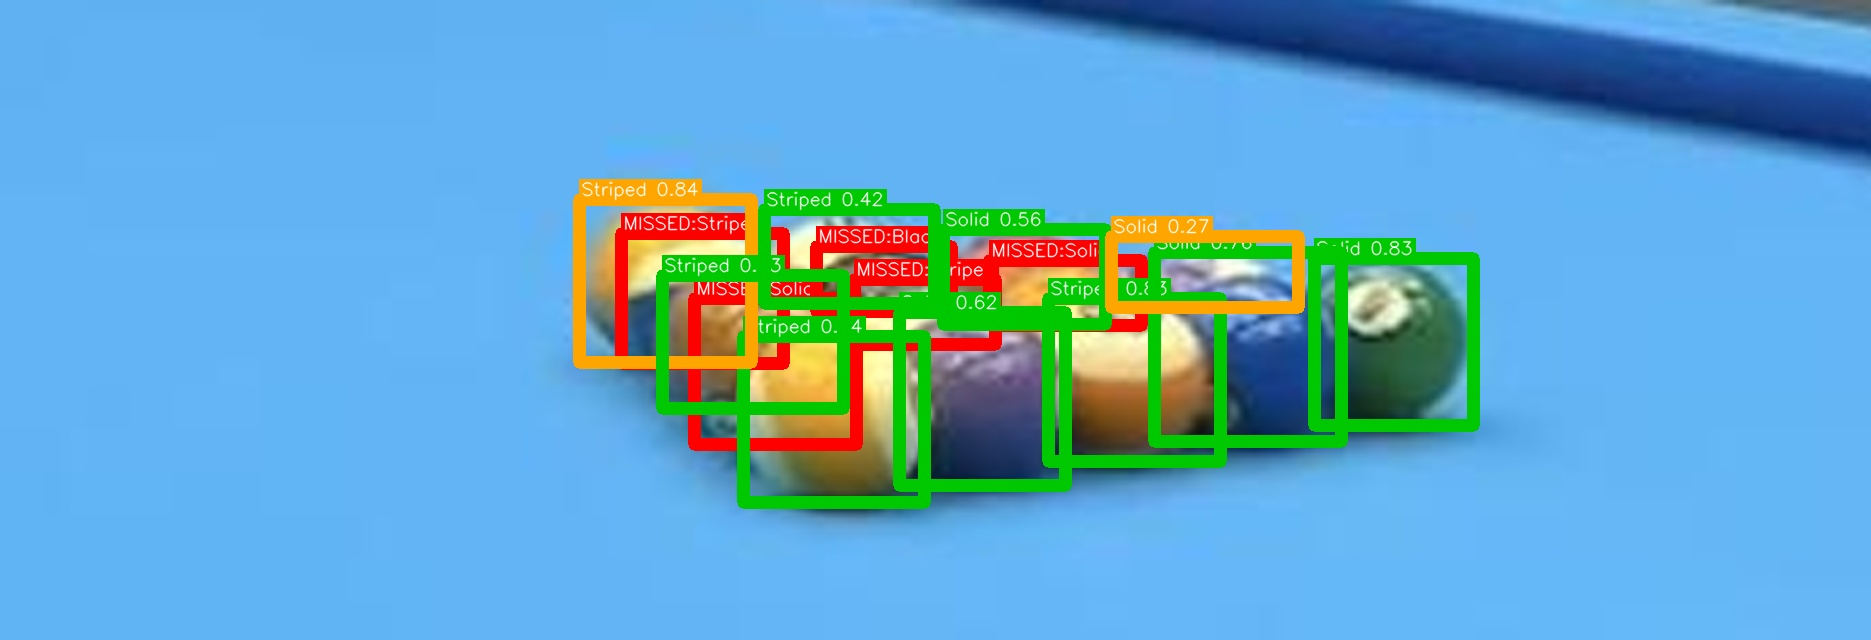

In [10]:
from PIL import Image

ERROR_ANALYSIS_DIR = Path("ball_detection/outputs/error_analysis/ball_detector_yolo11s_imgsz1280_no_dot_test")
Image.open(ERROR_ANALYSIS_DIR / "181_png.rf.23ccd3b4b31a6fef484f7f0d25cf89d7_error_zoom.jpg")

This is the worst single image in the whole test set: several low-confidence (0.27–0.84), overlapping, partially-misclassified boxes around the racked cluster, and multiple ground-truth balls left **MISSED** even though the model is clearly "reacting" to that region - it's just not localizing or classifying tightly enough to count as a correct match.
To check whether this was a one-off or a systematic pattern, we needed a way to measure "how close together are the balls in image X" - not just eyeball it. We wrote `analyze_clustering.py`, which for every ground-truth box computes the distance to its *nearest neighboring ball*, normalized by their average diagonal:

$$\text{ratio} = \frac{\text{center-to-center distance}}{\text{average ball diagonal}}$$

A ratio near **1.0** means the two balls are touching; **2.7+** means they're clearly separated. Each image's `min_ratio` is its closest pair - the worst case in that frame.

Only **26 of 207** training images (12.6%) have a genuinely touching ball pair. That scarcity is itself a candidate explanation for why exp04 still struggles there - but first we should confirm it's actually where the *test* errors concentrate, not just an interesting training-set fact. We extended `error_analysis.py` to tag each test image as "clustered" (`min_ratio ≤ 0.5`, same threshold) or not, and to total errors separately for each group.

In [11]:
exp04_errors = json.loads(Path("ball_detection/outputs/error_breakdown_exp04.json").read_text())

rows = []
for group in ["clustered", "non_clustered"]:
    totals = exp04_errors[group]
    n_errors = totals["missed"] + totals["fp"] + totals["miscls"]
    rows.append({
        "group": group,
        "test images": totals["n_images"],
        "ground-truth balls": totals["gt"],
        "missed": totals["missed"],
        "false positives": totals["fp"],
        "misclassified": totals["miscls"],
        "total errors": n_errors,
        "error rate": round(n_errors / totals["gt"], 3),
    })

stratified_exp04 = pd.DataFrame(rows).set_index("group")
stratified_exp04

,test images,ground-truth balls,missed,false positives,misclassified,total errors,error rate
group,,,,,,,
clustered,2,22,5,0,4,9,0.409
non_clustered,18,192,2,0,1,3,0.016


The disparity is stark: the 2 clustered test images hold only **22 of 214** ground-truth balls (10.3%) but account for **9 of the 12** total errors (75%) - a per-ball error rate of **40.9%**, against **1.6%** everywhere else. This confirms the touching-ball case isn't a minor edge case lost in the aggregate metrics; it's where almost all of the remaining error budget actually lives. That's what motivated the four targeted experiments in the next section.

### 4. Testing hypotheses for the touching-ball gap

#### 4.1 NMS IoU threshold - ruled out

YOLO's post-processing applies **class-aware Non-Max Suppression**: among predicted boxes of the *same class*, if two overlap by more than `iou_threshold`, the lower-confidence one is discarded as a duplicate. Two touching balls of the same class (e.g. two Solid balls side by side) naturally produce boxes with high mutual IoU - so at the default threshold (0.5), NMS could plausibly be discarding a *correct* detection of the second ball, mistaking it for a duplicate of the first. That's a clean, cheap-to-test, zero-retraining hypothesis: raise `iou_threshold` so two close-but-distinct boxes are both kept.

We re-ran exp04's exact weights at `iou_threshold = 0.7` instead of 0.5 and compared the same stratified breakdown.

In [12]:
def errors_table(*variants):
    """variants: list of (label, error_breakdown_dict)"""
    rows = []
    for label, totals in variants:
        for group in ["clustered", "non_clustered", "overall"]:
            g = totals[group]
            rows.append({
                "experiment": label,
                "group": group,
                "missed": g["missed"],
                "fp": g["fp"],
                "miscls": g["miscls"],
                "total errors": g["missed"] + g["fp"] + g["miscls"],
            })
    return pd.DataFrame(rows).set_index(["experiment", "group"])


exp04_iou07_errors = json.loads(Path("ball_detection/outputs/error_breakdown_exp04_iou07.json").read_text())

errors_table(
    ("exp04 (iou=0.5, default)", exp04_errors),
    ("exp04 (iou=0.7)", exp04_iou07_errors),
)

missed  fp  miscls  total errors
experiment               group                                          
exp04 (iou=0.5, default) clustered           5   0       4             9
                         non_clustered       2   0       1             3
                         overall             7   0       5            12
exp04 (iou=0.7)          clustered           3   1       5             9
                         non_clustered       2   0       1             3
                         overall             5   1       6            12

**Total errors are identical: 12 vs 12.** Raising the threshold didn't reduce errors, it just relabeled them - 2 fewer missed balls survived as boxes, but those boxes were still wrong enough (location or class) to count as a new false positive and an extra misclassification instead. This rules out NMS suppression as the bottleneck: the model isn't losing correct detections to over-eager NMS, it's failing to produce a *correct* detection in the first place on the touching balls. So the fix has to be on the learning/data side, not in post-processing.

#### 4.2 Oversampling clustered images with augmentation

If the model has only seen 26 genuinely-touching training examples, the natural next move is to make those 26 carry more weight - duplicate them with augmentation so the optimizer sees that pattern more often. The first version we tried added only **flip + photometric jitter** (brightness/contrast/saturation/noise) to 3 copies of each of the 26 images. That recovered some recall, but inspecting the worst image again showed the same number of total errors, just shifted - because every copy was still the *exact same ball geometry*, only recolored.

So we extended the augmentation to also include **geometric jitter** - small random rotation (±8°), scale (±8%), and translation (±4%) - with boxes recomputed as the axis-aligned bounding box of the transformed corners (and dropped if more than half their area is clipped off-frame). This is the version we kept and report below.

In [ ]:
from PIL import Image

Image.open("ball_detection/outputs/augmentation_example.png")

In [14]:
exp04_metrics = json.loads(Path("ball_detection/outputs/evaluation_test_exp04.json").read_text())
exp07_metrics = json.loads(Path("ball_detection/outputs/evaluation_test_exp07.json").read_text())
exp07_errors = json.loads(Path("ball_detection/outputs/error_breakdown_exp07.json").read_text())

rows = []
for label, metrics in [("exp04 (baseline)", exp04_metrics),
                        ("exp07 (+oversample, flip+photometric+geometric)", exp07_metrics)]:
    rows.append({
        "experiment": label,
        "precision": round(metrics["precision"], 3),
        "recall": round(metrics["recall"], 3),
        "mAP50": round(metrics["map50"], 3),
        "mAP50-95": round(metrics["map50_95"], 3),
    })
display(pd.DataFrame(rows).set_index("experiment"))

errors_table(
    ("exp04 (baseline)", exp04_errors),
    ("exp07 (+oversample, flip+photometric+geometric)", exp07_errors),
)

,precision,recall,mAP50,mAP50-95
experiment,,,,
exp04 (baseline),0.984,0.945,0.989,0.869
"exp07 (+oversample, flip+photometric+geometric)",0.984,0.939,0.984,0.873


missed  fp  \
experiment                                      group                       
exp04 (baseline)                                clustered           5   0   
                                                non_clustered       2   0   
                                                overall             7   0   
exp07 (+oversample, flip+photometric+geometric) clustered           4   0   
                                                non_clustered       2   0   
                                                overall             6   0   

                                                               miscls  \
experiment                                      group                   
exp04 (baseline)                                clustered           4   
                                                non_clustered       1   
                                                overall             5   
exp07 (+oversample, flip+photometric+geometric) clustered           6   
                                                non_clustered       1   
                                                overall             7   

                                                               total errors  
experiment                                      group                        
exp04 (baseline)                                clustered                 9  
                                                non_clustered             3  
                                                overall                  12  
exp07 (+oversample, flip+photometric+geometric) clustered                10  
                                                non_clustered             3  
                                                overall                  13

mAP50-95 improved slightly overall (0.869 -> 0.873), but recall actually dipped a touch (0.945 -> 0.939) and the clustered-image error count did not improve either (9 -> 10, just redistributed: fewer missed, more misclassified). Even with real geometric diversity added, the *same 26 underlying scenes* didn't generate a new occlusion pattern the model hadn't already seen - rotating/recoloring a rack doesn't change which ball is in front of which. This points away from "augmentation strategy" and toward genuine **data scarcity**: there may simply not be enough distinct clustered examples in this dataset for any synthetic variation of them to close the gap.

#### 4.3 Architecture comparison - RT-DETR

NMS turned out not to be the bottleneck (4.1), but it's still the most architecturally distinctive thing about YOLO's pipeline, so it was worth testing with a fundamentally different detector family: **RT-DETR**, a query-based, NMS-free architecture (one-to-one assignment during training instead of dense-grid-plus-suppression). It's natively supported by the same `ultralytics` package, so it drops into the same train/eval pipeline with no new infrastructure.

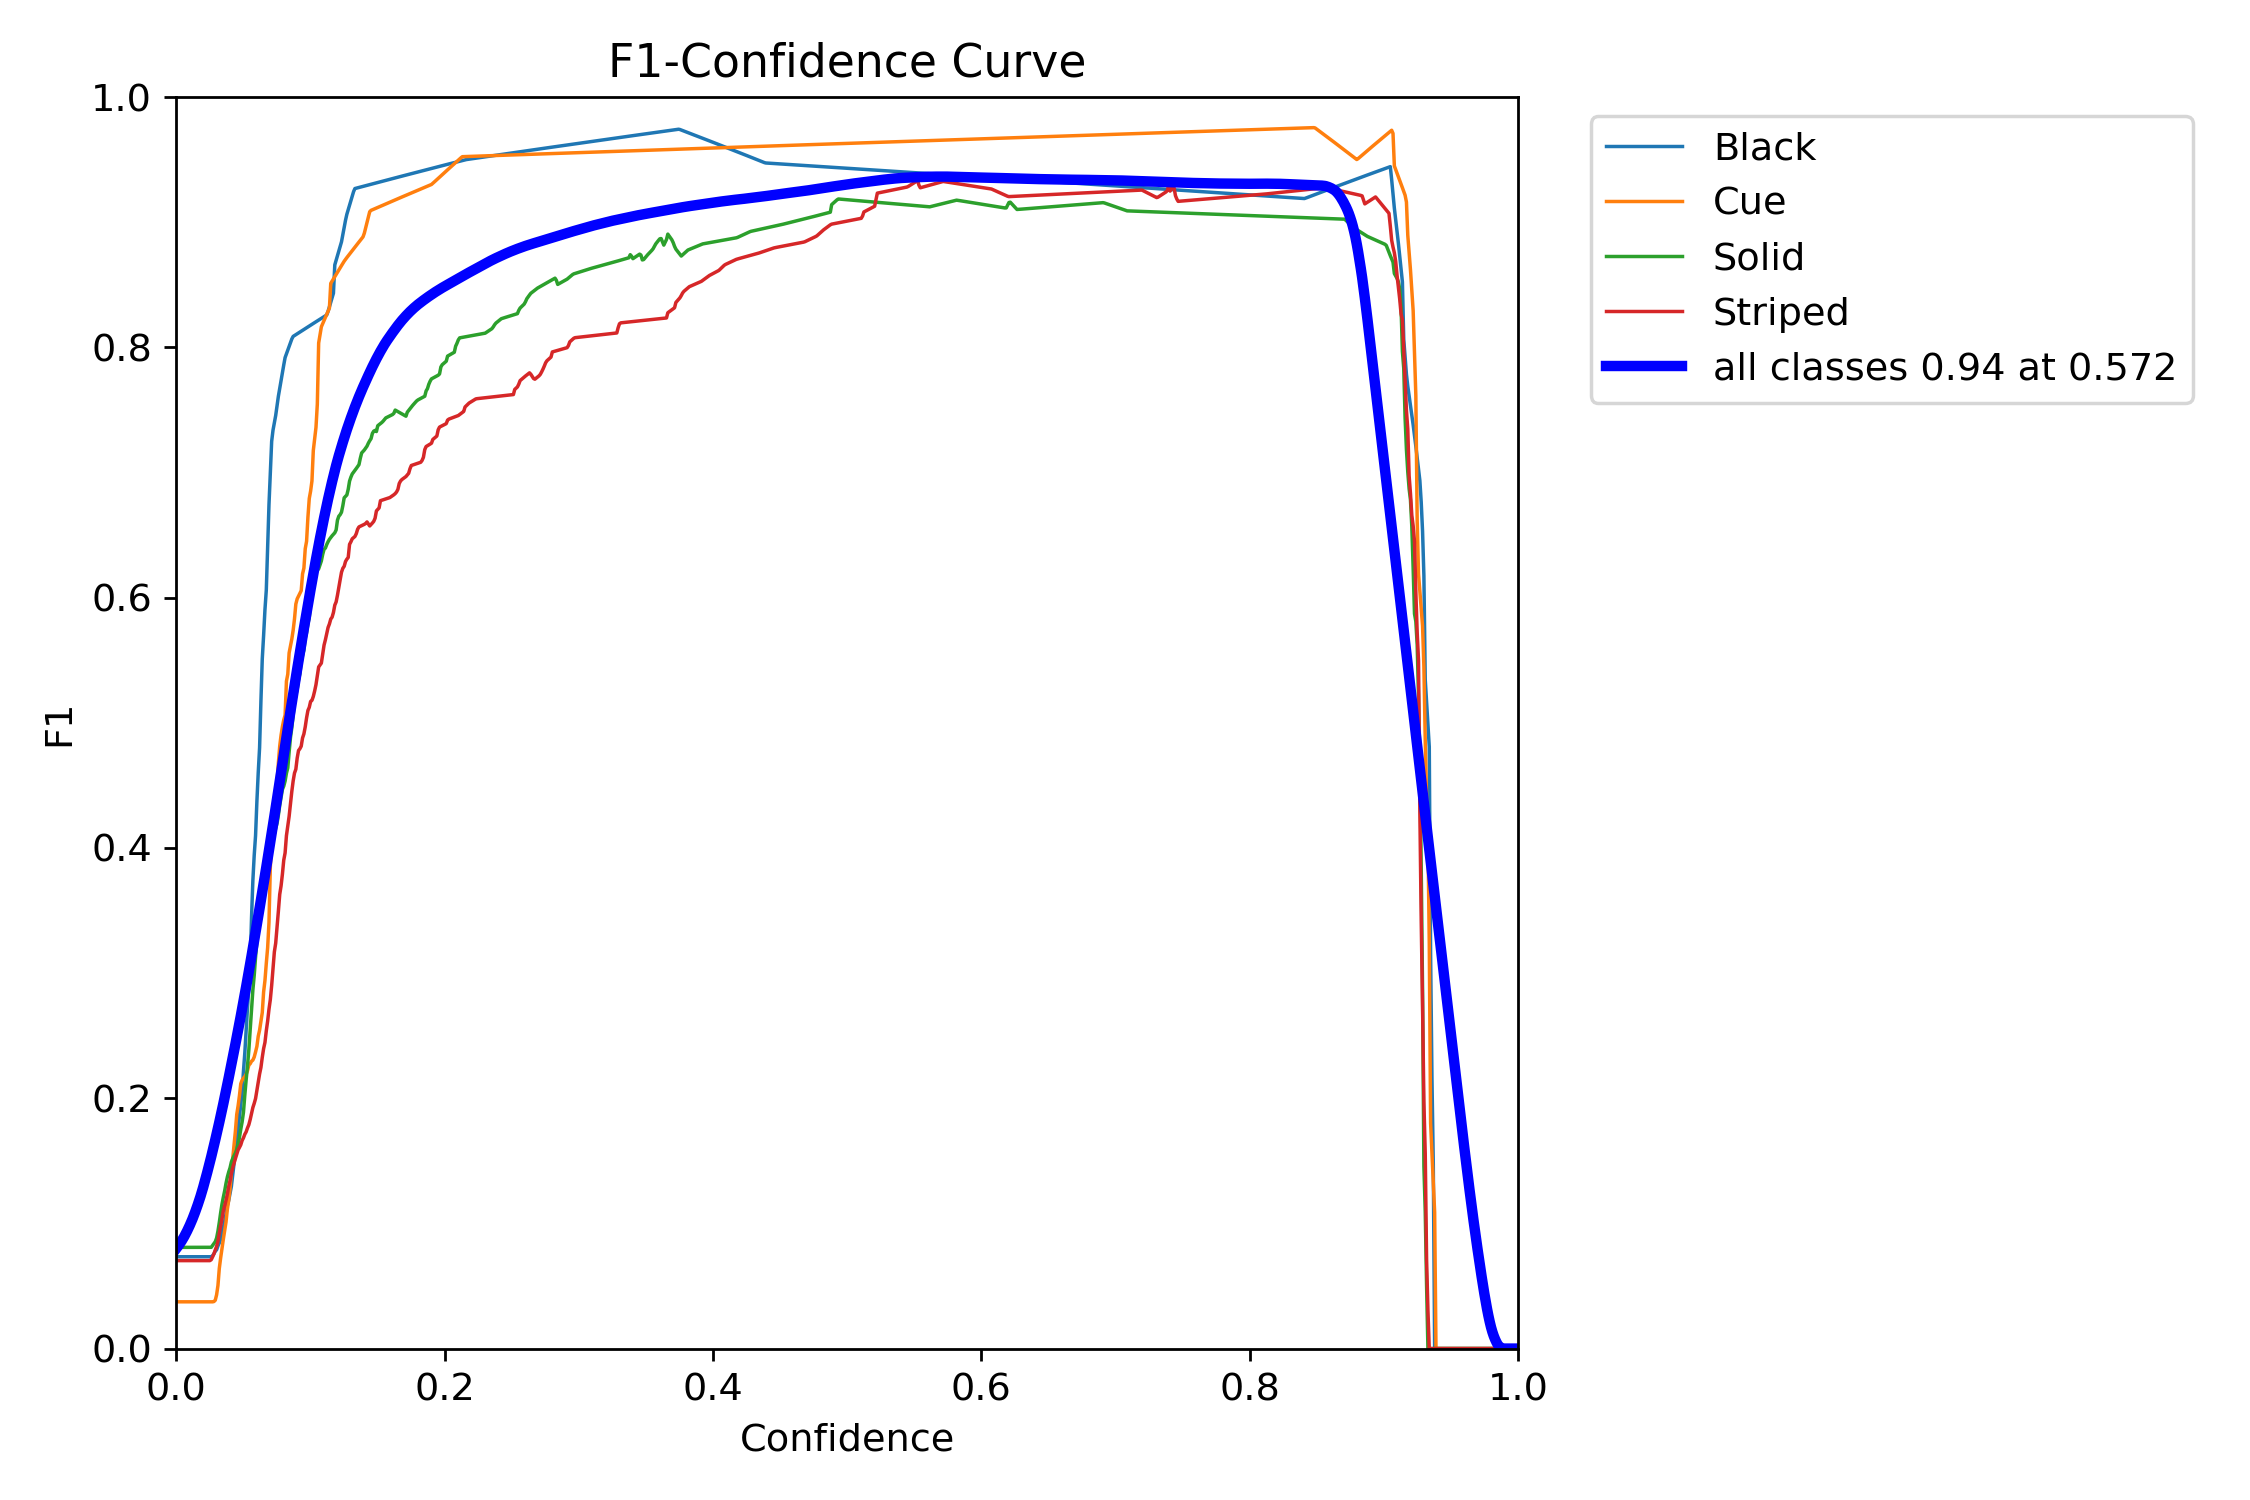

In [15]:
Image.open("ball_detection/outputs/eval_runs/ball_detector_rtdetr_l_imgsz1280_no_dot_test/BoxF1_curve.png")

Before comparing, this curve forced a methodology fix: RT-DETR's F1-optimal confidence threshold is **0.572**, not YOLO's conventional 0.25. At 0.25 - still the steep rising part of its curve - RT-DETR floods the output with low-confidence query noise (85 false positives across just 20 test images, evaluated naively). Query-based detectors emit a fixed number of object queries per image and aren't calibrated the same way anchor-based YOLO is, so comparing two architectures at the same fixed threshold is only fair if that threshold is each model's *own* optimum. All RT-DETR numbers below use **conf = 0.57**.

In [16]:
exp08_metrics = json.loads(Path("ball_detection/outputs/evaluation_test_exp08.json").read_text())
exp08_errors = json.loads(Path("ball_detection/outputs/error_breakdown_exp08.json").read_text())

rows = []
for label, metrics in [("exp04 (YOLO11s)", exp04_metrics), ("exp08 (RT-DETR-l, @conf=0.57)", exp08_metrics)]:
    rows.append({
        "experiment": label,
        "precision": round(metrics["precision"], 3),
        "recall": round(metrics["recall"], 3),
        "mAP50": round(metrics["map50"], 3),
        "mAP50-95": round(metrics["map50_95"], 3),
        "inference (ms/img)": round(metrics["speed_ms_per_image"]["inference"], 1),
    })
display(pd.DataFrame(rows).set_index("experiment"))

errors_table(
    ("exp04 (YOLO11s)", exp04_errors),
    ("exp08 (RT-DETR-l, @conf=0.57)", exp08_errors),
)

,precision,recall,mAP50,mAP50-95,inference (ms/img)
experiment,,,,,
exp04 (YOLO11s),0.984,0.945,0.989,0.869,5.1
"exp08 (RT-DETR-l, @conf=0.57)",0.934,0.943,0.978,0.886,26.3


missed  fp  miscls  total errors
experiment                    group                                          
exp04 (YOLO11s)               clustered           5   0       4             9
                              non_clustered       2   0       1             3
                              overall             7   0       5            12
exp08 (RT-DETR-l, @conf=0.57) clustered           6   1       4            11
                              non_clustered       5   8       2            15
                              overall            11   9       6            26

RT-DETR's mAP50-95 (0.886) is nominally the *best* of every model in this report - but that metric integrates over all confidence thresholds, not the one threshold you'd actually deploy at. At its own optimal operating point, it produces **more than double exp04's total errors** (26 vs 12), with most of the damage in the *non-clustered* images (15 errors there, including 8 false positives), and it's **5-6x slower** per image (26.3ms vs 5.1ms). The likely explanation is data volume: query-based detectors are known to need substantially more training data than anchor-based ones to reach good calibration, and 207 images is probably well below that point. This is also a useful methodological lesson in its own right: a single aggregate metric like mAP can rank a worse practical model first if you don't also check its behavior at a fixed, deployable threshold.

#### 4.4 Backbone-freezing ablation

This last one was inspired by [Sutrisno et al., 2026](https://doi.org/10.52436/1.jutif.2026.7.2.5699) (*JUTIF*), who fine-tune YOLO11 for head detection in dense, occluded crowds - a different domain, but the same underlying problem shape (small, mutually-occluding objects). They compare full fine-tuning against freezing the first 10 backbone layers (`freeze=10`) and find full fine-tuning still wins overall, framing freezing as a cheaper, "competitive" alternative rather than an occlusion-specific fix - the lever that mattered for *their* occlusion problem was input resolution, which is the same thing exp02->04 already tested here.

Still, it's worth re-testing on our own data: their training set is 1,397 images, ours is 207 - far more prone to a full fine-tune overfitting the backbone's low-level features to our small set of clustered examples. We checked that `freeze=10` maps onto YOLO11s exactly the way their paper describes (layers 0-9 are the Conv/C3k2/SPPF backbone; layer 10 onward - C2PSA, the neck, the detection head - stays trainable), then ran the same exp04 setup with the backbone frozen.

In [17]:
exp09_metrics = json.loads(Path("ball_detection/outputs/evaluation_test_exp09.json").read_text())
exp09_errors = json.loads(Path("ball_detection/outputs/error_breakdown_exp09.json").read_text())

rows = []
for label, metrics in [("exp04 (full fine-tune)", exp04_metrics), ("exp09 (frozen backbone, freeze=10)", exp09_metrics)]:
    rows.append({
        "experiment": label,
        "precision": round(metrics["precision"], 3),
        "recall": round(metrics["recall"], 3),
        "mAP50": round(metrics["map50"], 3),
        "mAP50-95": round(metrics["map50_95"], 3),
    })
display(pd.DataFrame(rows).set_index("experiment"))

errors_table(
    ("exp04 (full fine-tune)", exp04_errors),
    ("exp09 (frozen backbone, freeze=10)", exp09_errors),
)

,precision,recall,mAP50,mAP50-95
experiment,,,,
exp04 (full fine-tune),0.984,0.945,0.989,0.869
"exp09 (frozen backbone, freeze=10)",0.988,0.927,0.982,0.866


missed  fp  miscls  \
experiment                         group                               
exp04 (full fine-tune)             clustered           5   0       4   
                                   non_clustered       2   0       1   
                                   overall             7   0       5   
exp09 (frozen backbone, freeze=10) clustered           4   1       5   
                                   non_clustered       3   3       1   
                                   overall             7   4       6   

                                                  total errors  
experiment                         group                        
exp04 (full fine-tune)             clustered                 9  
                                   non_clustered             3  
                                   overall                  12  
exp09 (frozen backbone, freeze=10) clustered                10  
                                   non_clustered             7  
                                   overall                  17

Even at our much smaller scale, freezing the backbone did **not** outperform full fine-tuning - recall dropped (0.945 -> 0.927) and total errors rose (12 -> 17). This reproduces Sutrisno et al.'s own pattern (full fine-tune > freeze=10), just for a different likely reason: rather than overfitting prevention, it suggests the model genuinely needs the backbone's capacity to adapt COCO's natural-image priors to this domain's colors/textures (felt, ball plastics, lighting), not just the detection head. So the overfitting-risk hypothesis specific to our smaller dataset wasn't supported here.

### 5. Final comparison and discussion

In [18]:
summary_rows = []
for label, metrics, errors in [
    ("exp04 - YOLO11s baseline", exp04_metrics, exp04_errors),
    ("exp07 - + oversample (flip+photometric+geometric)", exp07_metrics, exp07_errors),
    ("exp08 - RT-DETR-l (@conf=0.57)", exp08_metrics, exp08_errors),
    ("exp09 - frozen backbone (freeze=10)", exp09_metrics, exp09_errors),
]:
    clustered = errors["clustered"]
    non_clustered = errors["non_clustered"]
    summary_rows.append({
        "experiment": label,
        "precision": round(metrics["precision"], 3),
        "recall": round(metrics["recall"], 3),
        "mAP50-95": round(metrics["map50_95"], 3),
        "speed (ms/img)": round(metrics["speed_ms_per_image"]["inference"], 1),
        "clustered errors (/22)": clustered["missed"] + clustered["fp"] + clustered["miscls"],
        "non-clustered errors (/192)": non_clustered["missed"] + non_clustered["fp"] + non_clustered["miscls"],
        "total errors": (clustered["missed"] + clustered["fp"] + clustered["miscls"]
                          + non_clustered["missed"] + non_clustered["fp"] + non_clustered["miscls"]),
    })

pd.DataFrame(summary_rows).set_index("experiment")

,precision,recall,mAP50-95,speed (ms/img),clustered errors (/22),non-clustered errors (/192),total errors
experiment,,,,,,,
exp04 - YOLO11s baseline,0.984,0.945,0.869,5.1,9,3,12
exp07 - + oversample (flip+photometric+geometric),0.984,0.939,0.873,4.6,10,3,13
exp08 - RT-DETR-l (@conf=0.57),0.934,0.943,0.886,26.3,11,15,26
exp09 - frozen backbone (freeze=10),0.988,0.927,0.866,4.9,10,7,17


**None of the four targeted interventions beat the plain exp04 baseline**, either overall or on the touching-ball subset specifically. Every one of NMS tuning, augmented oversampling, a different architecture, and backbone freezing came out flat-to-worse. **exp04 (YOLO11s, 1280px, full fine-tune, unmodified dataset) remains the production model.**

**Why we didn't also chase higher resolution or a bigger model.** Both are natural next levers, and both are bad trades here, by measurement rather than assumption:

- *Resolution:* in the worst test image, balls are already only ~19×15px at exp04's 1280px input. At the image's *native* resolution (1920×1080, i.e. the absolute ceiling - no downscaling at all), they're still only ~29×23px. There's roughly 1.5x of real headroom left before you'd be upsampling past the information the source footage actually contains, and even at that ceiling two ~23px circles touching each other share only a few pixels of boundary - a hard limit on separability that no resolution increase removes.
- *Bigger model:* RT-DETR-l already tested a much larger, structurally different model and didn't fix the touching-ball case, so capacity doesn't look like the remaining bottleneck. A bigger YOLO backbone (m/l/x) would also be more prone to overfitting on only 207 training images.

**Conclusion.** The residual touching-ball error is best explained by genuine data scarcity: only 26 of 207 training images (12.6%) contain a touching ball pair, and none of the interventions that work *with* that scarcity (synthetic augmentation, architecture change, regularization via freezing) closed the gap - because none of them add a training example with new ball-occlusion geometry. The most promising remaining lever is to annotate new data on the same tables but with more examples of clustered balls.

## **Table Retrieval**